# Step 0: Set Up Environment and Device


In [1]:
import torch
from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)
from datasets import load_dataset, DatasetDict
from transformers import TrainerCallback
import matplotlib.pyplot as plt
from transformers import get_scheduler



## Check if GPU is available


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


# Step 1: Load Pre-trained Model and Tokenizer


In [3]:
model_name = "gpt2"  # Replace with a larger model if needed
cache_dir = "./models_cache"

tokenizer = GPT2Tokenizer.from_pretrained(model_name, cache_dir=cache_dir)
model = GPT2LMHeadModel.from_pretrained(model_name, cache_dir=cache_dir).to(device)


# Step 2: Configure Special Tokens


In [4]:
special_tokens = {"pad_token": "[PAD]", "eos_token": tokenizer.eos_token}
tokenizer.add_special_tokens(special_tokens)
model.resize_token_embeddings(len(tokenizer))
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = tokenizer.pad_token_id


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


# Step 3: Preprocessing Function


In [5]:
def format_data(batch):
    input_texts = [
        f"Instruction: {instruction} \nInput: {inp} \nOutput:"
        for instruction, inp in zip(batch["instruction"], batch["input"])
    ]
    output_texts = batch["output"]

    tokenized_inputs = tokenizer(
        input_texts, truncation=True, padding="max_length", max_length=128
    )
    tokenized_outputs = tokenizer(
        output_texts, truncation=True, padding="max_length", max_length=128
    )

    return {
        "input_ids": tokenized_inputs["input_ids"],
        "attention_mask": tokenized_inputs["attention_mask"],
        "labels": tokenized_outputs["input_ids"],
    }



# Step 4: Load and Split Dataset


In [6]:
dataset_path = "../data/instruction_dataset.json"  # Path to your dataset
raw_datasets = load_dataset("json", data_files=dataset_path)

# Split into train (80%), validation (10%), and test (10%)
split_dataset = raw_datasets["train"].train_test_split(test_size=0.2, seed=42)
validation_test_split = split_dataset["test"].train_test_split(test_size=0.5, seed=42)

# Combine into a DatasetDict
final_datasets = DatasetDict({
    "train": split_dataset["train"],
    "validation": validation_test_split["train"],
    "test": validation_test_split["test"]
})


# Step 5: Preprocess the Dataset


In [7]:
tokenized_datasets = final_datasets.map(
    format_data, batched=True, remove_columns=["instruction", "input", "output"]
)

# Step 6: Define Data Collator


In [8]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer, mlm=False
)

# Step 7: Define Training Arguments


In [9]:
training_args = TrainingArguments(
    output_dir="./instruction_tuning_model",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,  # Log frequently for better insight
    save_total_limit=2,
    num_train_epochs=15,  # Reduce number of epochs
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,
    weight_decay=0.01,
    learning_rate=1e-9,  # Increase the learning rate
    warmup_steps=50,  # Short warmup for better initialization
    logging_dir="./logs",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

h:\Documents\Work\llm-zero-to-mastery\.venv\Lib\site-packages\transformers\training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


# Step 8: Train the Model


In [10]:
# Define the optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

# Define the scheduler
num_training_steps = len(tokenized_datasets["train"])
scheduler = get_scheduler(
    "linear",  # Linear decay
    optimizer=optimizer,
    num_warmup_steps=0.1 * num_training_steps,  # 10% warm-up
    num_training_steps=num_training_steps,
)


trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    optimizers=(optimizer, scheduler),
)

C:\Users\Asus\AppData\Local\Temp\ipykernel_17280\3667331566.py:14: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## Train the model and plot the evaluation loss


  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 4.947795867919922, 'eval_runtime': 0.0175, 'eval_samples_per_second': 57.084, 'eval_steps_per_second': 57.084, 'epoch': 1.0}


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 4.947795867919922, 'eval_runtime': 0.0172, 'eval_samples_per_second': 58.004, 'eval_steps_per_second': 58.004, 'epoch': 2.0}


...

{'eval_loss': 3.7787318229675293, 'eval_runtime': 0.04, 'eval_samples_per_second': 24.999, 'eval_steps_per_second': 24.999, 'epoch': 13.0}


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 3.7787318229675293, 'eval_runtime': 0.0365, 'eval_samples_per_second': 27.365, 'eval_steps_per_second': 27.365, 'epoch': 14.0}


  0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 3.7787318229675293, 'eval_runtime': 0.018, 'eval_samples_per_second': 55.556, 'eval_steps_per_second': 55.556, 'epoch': 15.0}
{'train_runtime': 23.9157, 'train_samples_per_second': 5.018, 'train_steps_per_second': 0.627, 'train_loss': 7.9129994710286455, 'epoch': 15.0}


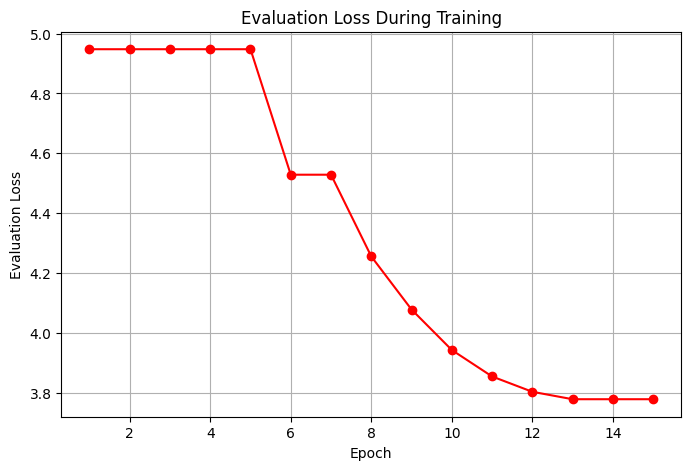

In [11]:
# Custom callback to log evaluation loss
class EvalLossCallback(TrainerCallback):
    def __init__(self):
        self.eval_losses = []
        self.epochs = []

    def on_evaluate(self, args, state, control, **kwargs):
        if "eval_loss" in state.log_history[-1]:
            self.eval_losses.append(state.log_history[-1]["eval_loss"])
            self.epochs.append(state.epoch)

# Initialize the callback
eval_loss_callback = EvalLossCallback()

# Add the callback to the Trainer
trainer.add_callback(eval_loss_callback)

# Train the model
trainer.train()

# Plot the evaluation loss
plt.figure(figsize=(8, 5))
plt.plot(eval_loss_callback.epochs, eval_loss_callback.eval_losses, marker='o', linestyle='-', color='r')
plt.title('Evaluation Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Evaluation Loss')
plt.grid(True)
plt.show()



# Step 9: Save the Fine-Tuned Model


In [12]:
model.save_pretrained("./instruction_tuning_model")
tokenizer.save_pretrained("./instruction_tuning_model")



('./instruction_tuning_model\\tokenizer_config.json',
 './instruction_tuning_model\\special_tokens_map.json',
 './instruction_tuning_model\\vocab.json',
 './instruction_tuning_model\\merges.txt',
 './instruction_tuning_model\\added_tokens.json')

# Step 10: Test the Fine-Tuned Model


In [14]:
def test_model(prompt):
    inputs = tokenizer(prompt, return_tensors="pt", padding=True, truncation=True).to(device)
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_length=100,
        num_beams=5,
        temperature=0.7,  # Apply randomness
        top_p=0.9,        # Nucleus sampling
        do_sample=True,   # Enable sampling
        early_stopping=True,
    )
    print(f"Prompt: {prompt}")
    print(f"Output: {tokenizer.decode(outputs[0], skip_special_tokens=True)}")


test_prompts = [
    "Instruction: Summarize the text \nInput: Large Language Models are powerful tools for text processing.",
    "Instruction: Translate to French \nInput: I would like a cup of coffee, please."
]

for prompt in test_prompts:
    test_model(prompt)


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Prompt: Instruction: Summarize the text 
Input: Large Language Models are powerful tools for text processing.
Output: Instruction: Summarize the text 
Input: Large Language Models are powerful tools for text processing. However, they are not the only tools that can be used to create large language models. In fact, there are many other tools that can also be used to create large language models. For example, there are many other tools that can also be used to create large language models. For example, there are many other tools that can also be used to create large language models. For example,
Prompt: Instruction: Translate to French 
Input: I would like a cup of coffee, please.
Output: Instruction: Translate to French 
Input: I would like a cup of coffee, please.
Input: I would like a cup of coffee, please.
Input: I would like a cup of coffee, please.
Input: I would like a cup of coffee, please.
Input: I would like a cup of coffee, please.
Input: I would like a cup of coffee, please.
